<a href="https://colab.research.google.com/github/engineerchacon/Procesamiento-de-Lenguaje-Natural/blob/main/Etiquetado_gramatical_Armando_Chac%C3%B3n_Terrazas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1.Importamos Librerias**

In [7]:
!python -m spacy download es_core_news_sm
# Librerías necesarias para el PLN y armar las gráficas
import spacy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from spacy import displacy

# Cargamos el modelo que acabamos de instalar
nlp = spacy.load("es_core_news_sm")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 89.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


# **2. Texto, procesamiento y tabla (bASADO EN Ejemplo 1 - POS Tagging)**

In [8]:
texto = """En los últimos años, muchas universidades han
incorporado herramientas digitales para apoyar el aprendizaje de los
estudiantes. Estas tecnologías permiten organizar materiales, facilitar la
comunicación y ofrecer actividades interactivas dentro y fuera del aula. Sin
embargo, su uso no siempre garantiza mejores resultados académicos, porque
también depende de la planeación del docente y del compromiso del alumno. En
algunos cursos, los estudiantes participan más cuando utilizan plataformas
virtuales, foros o sistemas de retroalimentación inmediata. Además, los
profesores pueden analizar con mayor facilidad el avance del grupo y detectar
dificultades en temas específicos. Por esta razón, el uso de recursos
tecnológicos se ha convertido en un tema relevante para la educación actual."""

# Procesamos todo el texto
doc = nlp(texto)

print(f"{'Token':<15}{'UPOS':<10}{'FEATS':<40}{'DEPREL':<10}")
print("-" * 75)

# Listas para guardar los datos limpios que usaremos en las gráficas de la última celda
tokens_limpios = []
etiquetas_limpias = []

for token in doc:
    # Ignoramos espacios y saltos de línea para no ensuciar los datos
    if not token.is_space:
        tokens_limpios.append(token.text)
        etiquetas_limpias.append(token.pos_)

        # Imprimimos la fila de la tabla
        feats = str(token.morph)
        print(f"{token.text:<15}{token.pos_:<10}{feats:<40}{token.dep_:<10}")

Token          UPOS      FEATS                                   DEPREL    
---------------------------------------------------------------------------
En             ADP                                               case      
los            DET       Definite=Def|Gender=Masc|Number=Plur|PronType=Artdet       
últimos        ADJ       Gender=Masc|NumType=Ord|Number=Plur     amod      
años           NOUN      Gender=Masc|Number=Plur                 obl       
,              PUNCT     PunctType=Comm                          punct     
muchas         DET       Gender=Fem|NumType=Card|Number=Plur|PronType=Inddet       
universidades  NOUN      Gender=Fem|Number=Plur                  nsubj     
han            AUX       Mood=Ind|Number=Plur|Person=3|Tense=Pres|VerbForm=Finaux       
incorporado    ADJ       Gender=Masc|Number=Sing|VerbForm=Part   amod      
herramientas   NOUN      Gender=Fem|Number=Plur                  ROOT      
digitales      ADJ       Number=Plur                      

# **3. Árbol de dependencias**

In [9]:
# Agarramos solo la primera oración para que el diagrama no sea inmenso e ilegible
primera_oracion = list(doc.sents)[0]

# Lo renderizamos directo en el output de la celda de Colab
displacy.render(primera_oracion, style="dep", jupyter=True)

# **4. Análisis Exploratorio (EDA) y gráficas.**

--- RESULTADOS DEL ANÁLISIS ---

a. Número total de tokens: 125
b. Número de tokens distintos: 91



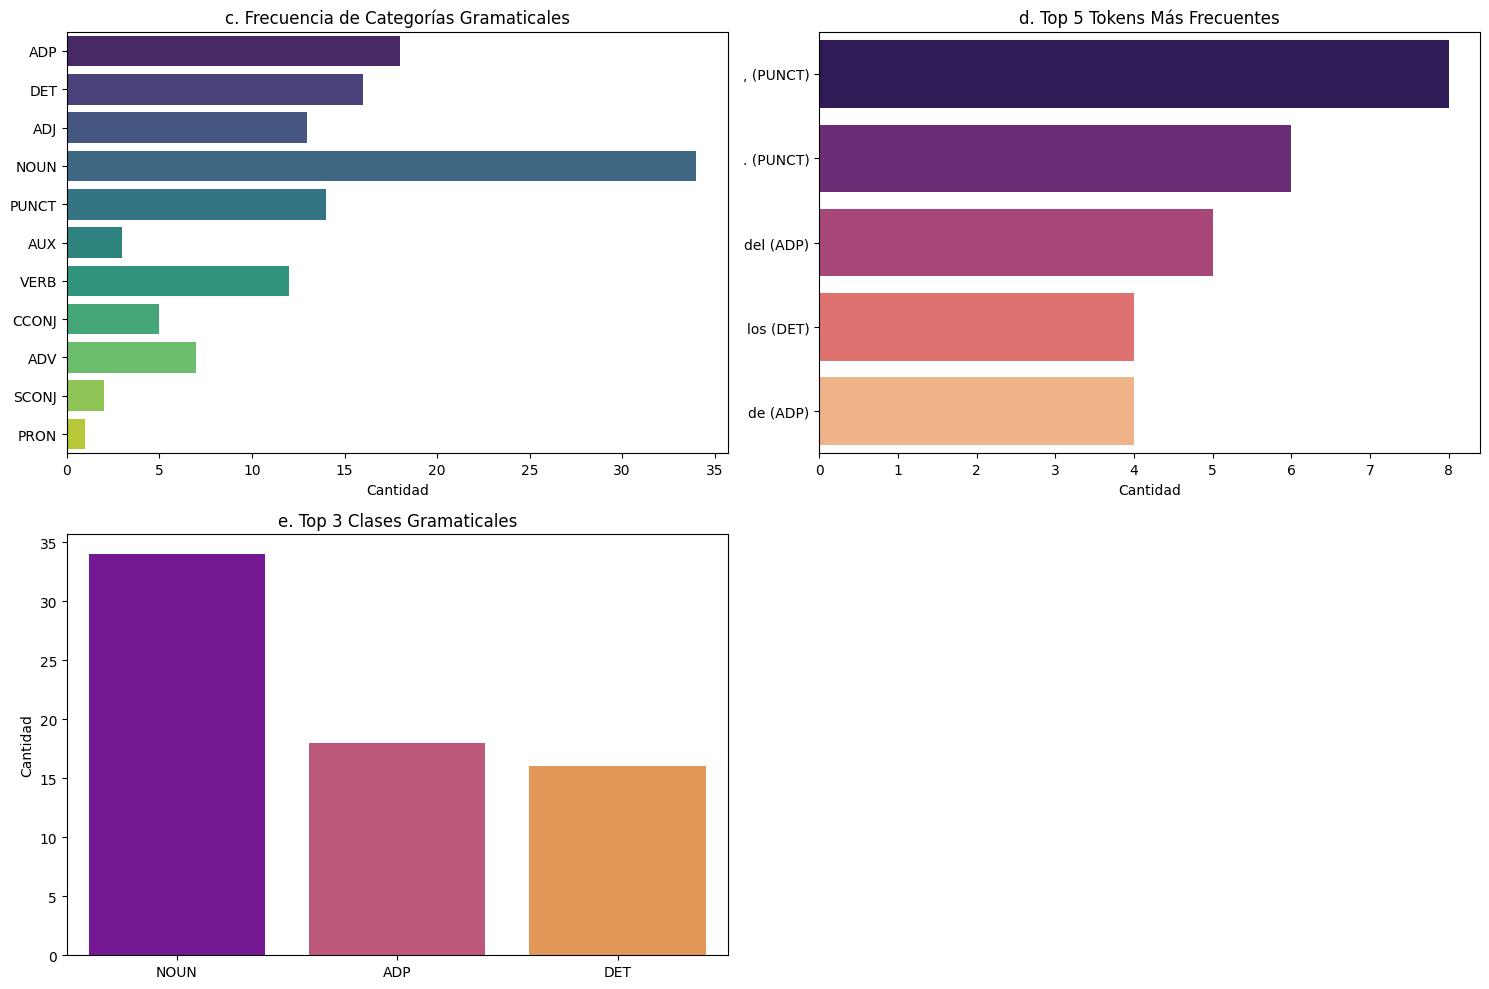

In [11]:
print("--- RESULTADOS DEL ANÁLISIS ---\n")

# a y b. Conteos básicos
print(f"a. Número total de tokens: {len(tokens_limpios)}")
print(f"b. Número de tokens distintos: {len(set(tokens_limpios))}\n")

# Armamos el lienzo para que quepan bien las 3 gráficas
plt.figure(figsize=(15, 10))

# c. Frecuencia de todas las categorías (Gráfica 1)
plt.subplot(2, 2, 1)
conteo_etiquetas = Counter(etiquetas_limpias)
nombres_c = list(conteo_etiquetas.keys())
valores_c = list(conteo_etiquetas.values())
sns.barplot(x=valores_c, y=nombres_c, hue=nombres_c, legend=False, palette="viridis")
plt.title("c. Frecuencia de Categorías Gramaticales")
plt.xlabel("Cantidad")

# d. Top 5 Tokens (Gráfica 2)
plt.subplot(2, 2, 2)
pares = list(zip(tokens_limpios, etiquetas_limpias))
top_5 = Counter(pares).most_common(5)
nombres_top_5 = [f"{par[0][0]} ({par[0][1]})" for par in top_5]
valores_top_5 = [par[1] for par in top_5]
sns.barplot(x=valores_top_5, y=nombres_top_5, hue=nombres_top_5, legend=False, palette="magma")
plt.title("d. Top 5 Tokens Más Frecuentes")
plt.xlabel("Cantidad")

# e. Top 3 Clases Gramaticales (Gráfica 3)
plt.subplot(2, 2, 3)
top_3_etiquetas = conteo_etiquetas.most_common(3)
nombres_top_3 = [x[0] for x in top_3_etiquetas]
valores_top_3 = [x[1] for x in top_3_etiquetas]
sns.barplot(x=nombres_top_3, y=valores_top_3, hue=nombres_top_3, legend=False, palette="plasma")
plt.title("e. Top 3 Clases Gramaticales")
plt.ylabel("Cantidad")

# Ajustamos para que no se encimen y mostramos
plt.tight_layout()
plt.show()